# Random forest

In [1]:
import pandas as pd
import numpy as np
import math
import os
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, recall_score,ConfusionMatrixDisplay
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.cm as cm
import random
import scipy.signal as sp
from IPython.display import display
from scipy.stats import kruskal

In [2]:
Train=pd.read_csv(r'F:\graduation project\data\Code\final\ecg 60s 10min\features\train.csv')
Valid=pd.read_csv(r'F:\graduation project\data\Code\final\ecg 60s 10min\features\valid.csv')

In [3]:
Train.head(5)

,meanHR,stdHR,minHR,maxHR,Delta_HR,meanRR_ms,SDNN_ms,RMSSD_ms,pNN50,meanHRV_bpm,mean_ecg,std_ecg,rms_ecg,ptp_ecg,total_power_ecg,bp_0_5_3_ecg,n_beats,encoded_label
0,63.819830,19.762804,50.826131,140.159228,6.243052,971.135675,256.101730,254.833614,19.124514,61.783338,0.440349,0.003677,0.440364,0.038819,0.000054,0.000004,61.445039,2
1,69.111552,2.978145,66.033971,78.089745,5.137814,870.295685,33.932681,8.721901,0.000000,68.943007,0.701162,0.022981,0.701563,0.228766,0.002125,0.000139,68.000000,2
2,78.509008,2.897538,70.803542,84.968223,0.357832,763.997636,28.966669,15.757633,0.000000,78.535093,0.725042,0.067575,0.728184,0.522522,0.018294,0.001755,78.000000,0
3,69.987791,3.257098,62.950820,77.969543,0.286578,856.847426,41.782432,27.875787,2.941176,70.024135,0.676032,0.070067,0.679653,0.698801,0.019583,0.000437,69.000000,2
4,71.416697,8.967358,36.923077,81.269841,31.616111,844.084821,156.393931,155.809217,4.285714,71.082904,0.536042,0.026683,0.536705,0.277270,0.002892,0.000171,71.000000,1


In [4]:
data=pd.read_csv(r'F:\graduation project\data\Code\final\ecg 60s 10min\features\combined_data.csv')

In [5]:
def convert(df, label_col='label'):

    df = df.copy()
    df.loc[df[label_col] == 'postictal', label_col] = 'normal'
    return df
data = convert(data)

In [6]:
def Encode_Labels(df, label_col='label'):
    encoder = LabelEncoder()
    df['encoded_label'] = encoder.fit_transform(df[label_col])

    print(" Multiclass encoding applied successfully!")
    print("Class mapping:")
    for cls, code in zip(encoder.classes_, encoder.transform(encoder.classes_)):
        print(f"  {cls} → {code}")

    return df

data = Encode_Labels(data)

 Multiclass encoding applied successfully!
Class mapping:
  ictal → 0
  normal → 1
  preictal → 2
  nan → 3


In [7]:
label_counts = data['status'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,success,128532
1,error: cannot convert float NaN to integer,9
2,error: index 9 is out of bounds for axis 0 wit...,9
3,error: integer division or modulo by zero,6
4,error: index 10 is out of bounds for axis 0 wi...,3


In [8]:
data= data[data['status'] == 'success']
label_counts = data['status'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,success,128532


In [9]:
label_counts = data['encoded_label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,1,115966
1,2,9575
2,0,2991


In [10]:
target_col = 'encoded_label'

exclude_cols =   [  'label', 'sex','run', 'start_time', 'end_time', 'eventtype', 'status', 'Delta_HR',
    'signal', 'times', 'R_peaks', 'RR_intervals', 'HR_series','encoded_label']
feature_cols = [c for c in Train.columns if c not in exclude_cols]

X_Train = Train[feature_cols]
Y_Train = Train[target_col]

X_Valid = Valid[feature_cols]
Y_Valid = Valid[target_col]

### Randomforest

In [11]:
n_estimators_options = [50, 100, 150]  
max_depth_options = [10, 20]          
min_samples_leaf_options = [2, 5] 
preictal_thresholds = [0.35, 0.5]  

train_acc_list = []
valid_acc_list = []
train_loss_list = []
valid_loss_list = []
valid_recall_ictal_list = []

best_valid_recall = 0
best_model = None
best_params = {}

for max_d in max_depth_options:
    for min_leaf in min_samples_leaf_options:
        for n in n_estimators_options:
            model = RandomForestClassifier(
                n_estimators=n,
                max_depth=max_d,
                min_samples_leaf=min_leaf,
                random_state=42
            )
            model.fit(X_Train, Y_Train)
            
            y_train_proba = model.predict_proba(X_Train)
            y_valid_proba = model.predict_proba(X_Valid)
            
            y_train_pred = np.argmax(y_train_proba, axis=1)
            
            for threshold in preictal_thresholds:
                preictal_prob_valid = y_valid_proba[:, 2]
                y_valid_pred = np.where(
                    preictal_prob_valid > threshold, 2,
                    np.argmax(y_valid_proba, axis=1) )
                
                train_acc = accuracy_score(Y_Train, y_train_pred)
                valid_acc = accuracy_score(Y_Valid, y_valid_pred)
                train_loss = log_loss(Y_Train, y_train_proba)
                valid_loss = log_loss(Y_Valid, y_valid_proba)
                
                important_mask = np.isin(Y_Valid, [0, 2])
                important_recall = recall_score(
                    Y_Valid[important_mask],
                    y_valid_pred[important_mask],
                    average='micro')
                
                train_acc_list.append(train_acc)
                valid_acc_list.append(valid_acc)
                train_loss_list.append(train_loss)
                valid_loss_list.append(valid_loss)
                valid_recall_ictal_list.append(important_recall)
                
                if important_recall > best_valid_recall:
                    best_valid_recall = important_recall
                    best_model = model
                    best_params = {
                        'n_estimators': n,
                        'max_depth': max_d,
                        'min_samples_leaf': min_leaf,
                        'preictal_threshold': threshold}
                
                print(f"n_estimators={n}, max_depth={max_d}, min_samples_leaf={min_leaf}, threshold={threshold:.2f} | "
                      f"Train Acc={train_acc:.4f}, Valid Acc={valid_acc:.4f}, "
                      f"Train Loss={train_loss:.4f}, Valid Loss={valid_loss:.4f}, "
                      f"Recall(Ictal/Pre-ictal)={important_recall:.4f}")

print("\nBest Model Parameters:", best_params)
print("Best Valid Recall (Ictal/Pre-ictal):", best_valid_recall)


n_estimators=50, max_depth=10, min_samples_leaf=2, threshold=0.35 | Train Acc=0.9403, Valid Acc=0.3763, Train Loss=0.2746, Valid Loss=0.9909, Recall(Ictal/Pre-ictal)=0.8150
n_estimators=50, max_depth=10, min_samples_leaf=2, threshold=0.50 | Train Acc=0.9403, Valid Acc=0.4649, Train Loss=0.2746, Valid Loss=0.9909, Recall(Ictal/Pre-ictal)=0.6195
n_estimators=100, max_depth=10, min_samples_leaf=2, threshold=0.35 | Train Acc=0.9420, Valid Acc=0.3760, Train Loss=0.2720, Valid Loss=1.0274, Recall(Ictal/Pre-ictal)=0.8025
n_estimators=100, max_depth=10, min_samples_leaf=2, threshold=0.50 | Train Acc=0.9420, Valid Acc=0.4609, Train Loss=0.2720, Valid Loss=1.0274, Recall(Ictal/Pre-ictal)=0.6341
n_estimators=150, max_depth=10, min_samples_leaf=2, threshold=0.35 | Train Acc=0.9418, Valid Acc=0.3672, Train Loss=0.2723, Valid Loss=1.0122, Recall(Ictal/Pre-ictal)=0.8067
n_estimators=150, max_depth=10, min_samples_leaf=2, threshold=0.50 | Train Acc=0.9418, Valid Acc=0.4656, Train Loss=0.2723, Valid Lo

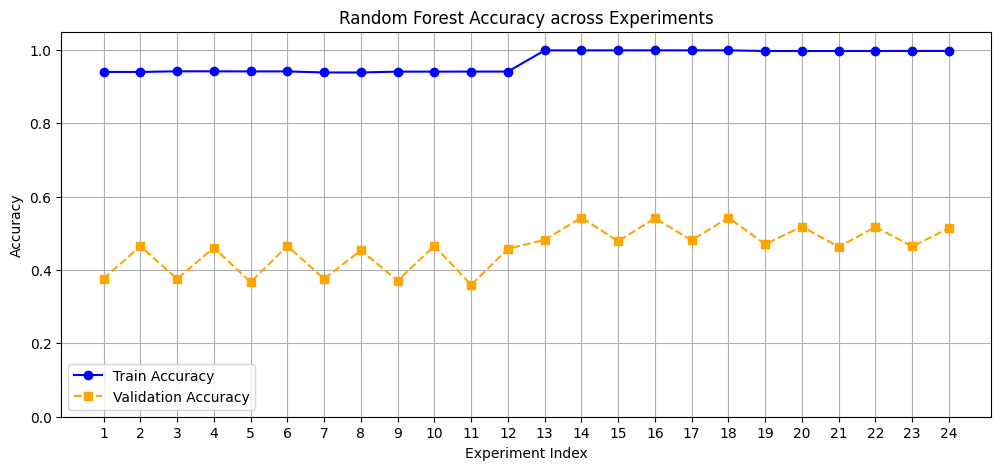

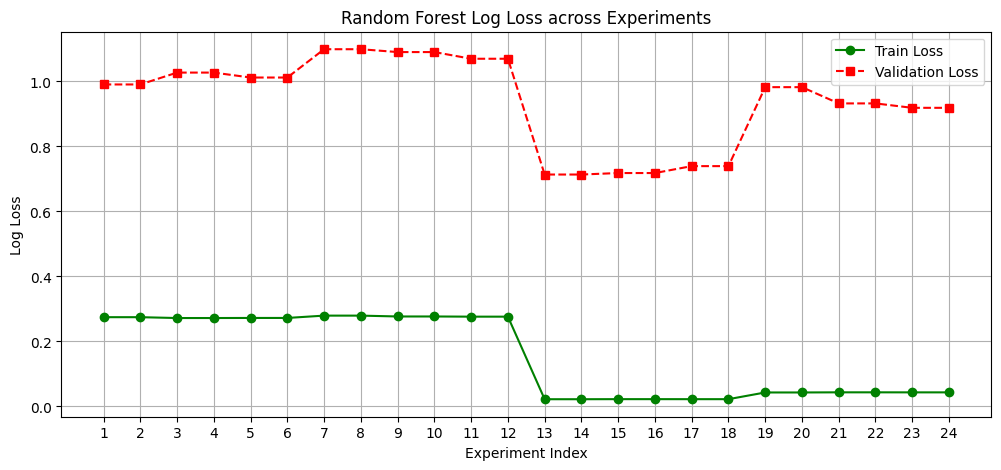

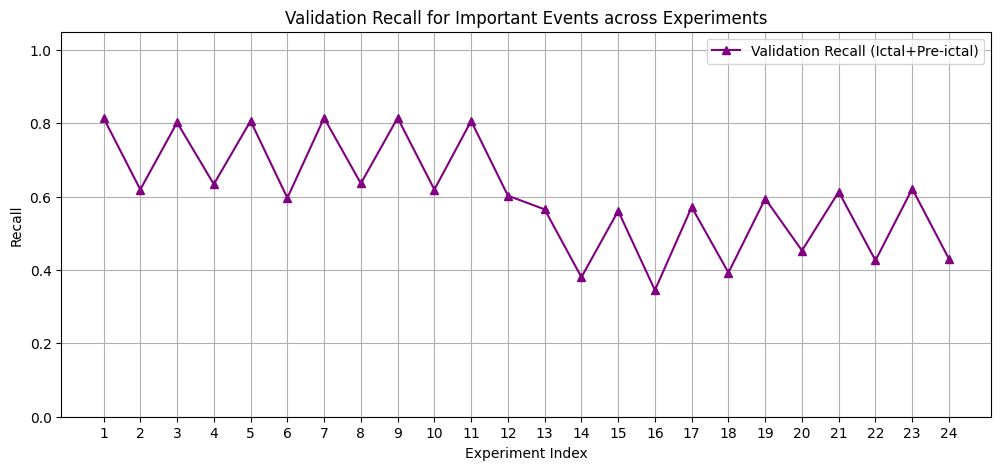

In [12]:
x_axis = list(range(1, len(train_acc_list)+1))

plt.figure(figsize=(12,5))
plt.plot(x_axis, train_acc_list, marker='o', linestyle='-', color='blue', label='Train Accuracy')
plt.plot(x_axis, valid_acc_list, marker='s', linestyle='--', color='orange', label='Validation Accuracy')
plt.xlabel("Experiment Index")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy across Experiments")
plt.xticks(x_axis)
plt.ylim(0,1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(x_axis, train_loss_list, marker='o', linestyle='-', color='green', label='Train Loss')
plt.plot(x_axis, valid_loss_list, marker='s', linestyle='--', color='red', label='Validation Loss')
plt.xlabel("Experiment Index")
plt.ylabel("Log Loss")
plt.title("Random Forest Log Loss across Experiments")
plt.xticks(x_axis)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(x_axis, valid_recall_ictal_list, marker='^', linestyle='-', color='purple', label='Validation Recall (Ictal+Pre-ictal)')
plt.xlabel("Experiment Index")
plt.ylabel("Recall")
plt.title("Validation Recall for Important Events across Experiments")
plt.xticks(x_axis)
plt.ylim(0,1.05)
plt.legend()
plt.grid(True)
plt.show()


In [13]:
print("\nBest Model Parameters:", best_params)
print("Best Valid Recall (Ictal/Pre-ictal):", best_valid_recall)


Best Model Parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_leaf': 2, 'preictal_threshold': 0.35}
Best Valid Recall (Ictal/Pre-ictal): 0.814968814968815


In [14]:
y_test_proba = best_model.predict_proba(X_Valid)

preictal_index = np.where(best_model.classes_ == 2)[0][0]
preictal_prob_test = y_test_proba[:, preictal_index]

y_val_pred_best = np.where(
    preictal_prob_test > best_params['preictal_threshold'], 
    2,  
    np.argmax(y_test_proba, axis=1)  )

<Figure size 700x700 with 0 Axes>

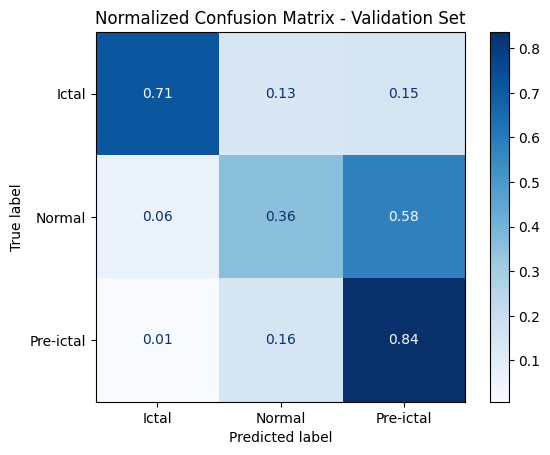

Final Test Accuracy: 0.3763
Confusion Matrix (Valid Set):
[[  300    55    65]
 [ 3565 20070 32505]
 [   15   310  1660]]


<Figure size 700x700 with 0 Axes>

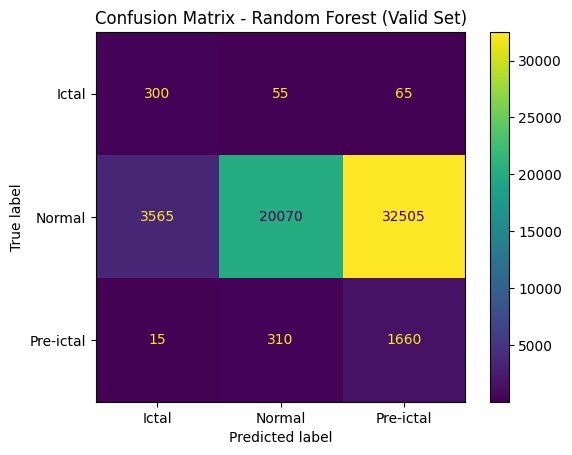

In [15]:
cm = confusion_matrix(Y_Valid, y_val_pred_best, normalize='true')  
class_names = ['Ictal', 'Normal', 'Pre-ictal']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(7,7))
disp.plot(cmap='Blues', values_format='.2f')
plt.title("Normalized Confusion Matrix - Validation Set")
plt.show()


y_test_pred = y_val_pred_best
test_acc = accuracy_score(Y_Valid, y_test_pred)
print(f"Final Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(Y_Valid, y_test_pred)

print("Confusion Matrix (Valid Set):")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(7,7))
disp.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest (Valid Set)")
plt.show()

In [16]:
y_valid_proba = best_model.predict_proba(X_Valid)
y_valid_pred = np.argmax(y_valid_proba, axis=1)

In [17]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

labels = [0, 1, 2]

# ===============================
# F1 / Precision / Recall
# ===============================
precision, recall, f1, _ = precision_recall_fscore_support(
    Y_Valid,
    y_valid_pred,
    labels=labels,
    zero_division=0
)

macro_f1 = np.mean(f1)

# ===============================
# ROC-AUC (One-vs-Rest)
# ===============================
y_true_bin = label_binarize(Y_Valid, classes=[0,1,2])

roc_auc = roc_auc_score(
    y_true_bin,
    y_valid_proba,
    multi_class='ovr',
    average='macro'
)

print("\n==============================")
print("OVERALL METRICS")
print("==============================")
print(f"Macro F1-score : {macro_f1:.4f}")
print(f"Macro ROC-AUC  : {roc_auc:.4f}")


class_names = ['ictal', 'normal', 'preictal']

print("\n==============================")
print("CLASS-WISE PERFORMANCE")
print("==============================")

for i, cls in enumerate(class_names):
    print(f"\nClass: {cls}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall   : {recall[i]:.4f}")
    print(f"F1-score : {f1[i]:.4f}")



OVERALL METRICS
Macro F1-score : 0.2797
Macro ROC-AUC  : 0.6689

CLASS-WISE PERFORMANCE

Class: ictal
Precision: 0.0761
Recall   : 0.7381
F1-score : 0.1379

Class: normal
Precision: 0.9675
Recall   : 0.4583
F1-score : 0.6220

Class: preictal
Precision: 0.0423
Recall   : 0.5945
F1-score : 0.0790


In [18]:
print("\n==============================")
print("SEIZURE-FOCUSED METRICS")
print("==============================")

ictal_idx = 0
preictal_idx = 2

print(f"Ictal Recall    : {recall[ictal_idx]:.4f}")
print(f"Preictal Recall : {recall[preictal_idx]:.4f}")
print(f"Preictal F1     : {f1[preictal_idx]:.4f}")


SEIZURE-FOCUSED METRICS
Ictal Recall    : 0.7381
Preictal Recall : 0.5945
Preictal F1     : 0.0790


### Personalized

In [19]:
data["window_id"] = data.groupby("subject").cumcount()


In [20]:
data.columns

Index(['subject', 'run', 'sex', 'start_time', 'end_time', 'eventtype', 'label',
       'signal', 'times', 'R_peaks', 'RR_intervals_ms', 'HR_series', 'status',
       'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms',
       'RMSSD_ms', 'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg',
       'ptp_ecg', 'total_power_ecg', 'bp_0_5_3_ecg', 'n_beats',
       'encoded_label', 'window_id'],
      dtype='object')

In [21]:
# Group by subject وأخذ آخر window_id لكل مريض
last_windows = data.groupby("subject")["window_id"].max().reset_index()
last_windows.rename(columns={"window_id": "last_window_id"}, inplace=True)

print(last_windows)


    subject  last_window_id
0      75.0           12899
1      76.0            9590
2      81.0            4229
3      83.0            1046
4      84.0            3452
5      85.0            3189
6      86.0            3512
7      88.0             964
8      89.0            5105
9      90.0            3767
10     91.0            1061
11     93.0            1052
12     94.0            2666
13     95.0            1046
14     96.0             854
15    100.0           24759
16    110.0           29629
17    118.0           10715
18    121.0            2282
19    122.0            2495
20    123.0            1103
21    124.0             881
22    125.0            2213


In [22]:
general_model = best_model 
preictal_threshold = best_params['preictal_threshold']

In [23]:
feature_cols = [
    'meanHR', 'stdHR', 'minHR', 'maxHR', 'meanRR_ms',
    'SDNN_ms','RMSSD_ms','pNN50','meanHRV_bpm','mean_ecg','std_ecg',
    'rms_ecg','ptp_ecg','total_power_ecg','bp_0_5_3_ecg','n_beats']

In [24]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# =====================================================
# 0) SETUP
# =====================================================
models_folder = "patient_models100_csv"
os.makedirs(models_folder, exist_ok=True)

patient_ids = data['subject'].unique()

# =====================================================
# LOOP OVER PATIENTS
# =====================================================
for pid in patient_ids:
    print(f"\n=== Processing Patient {pid} ===")
    
    patient_df = data[data['subject'] == pid].copy()
    
    # =====================================================
    # 1) CHECK REQUIRED COLUMNS
    # =====================================================
    assert "window_id" in patient_df.columns
    assert "run" in patient_df.columns
    
    # =====================================================
    # 2) IDENTIFIERS
    # =====================================================
    window_ids = patient_df["window_id"]
    run_ids = patient_df["run"]
    
    # =====================================================
    # 3) FEATURES & LABELS
    # =====================================================
    X_patient = patient_df[feature_cols]
    y_patient = patient_df["encoded_label"]   # 0,1,2
    
    # =====================================================
    # 4) TRAIN / TEST SPLIT
    # =====================================================
    X_train, X_test, y_train, y_test, win_train, win_test, run_train, run_test = train_test_split(
        X_patient,
        y_patient,
        window_ids,
        run_ids,
        test_size=0.2,
        random_state=42,
        stratify=y_patient
    )
    
    # =====================================================
    # 5) SAVE TRAIN & TEST DATA
    # =====================================================
    train_df = X_train.copy()
    train_df["window_id"] = win_train.values
    train_df["run"] = run_train.values
    train_df["label"] = y_train.values

    test_df = X_test.copy()
    test_df["window_id"] = win_test.values
    test_df["run"] = run_test.values
    test_df["label"] = y_test.values

    train_filename = os.path.join(models_folder, f"patient_{pid}_train.csv")
    test_filename = os.path.join(models_folder, f"patient_{pid}_test.csv")

    train_df.to_csv(train_filename, index=False)
    test_df.to_csv(test_filename, index=False)

    print(f"Saved TRAIN CSV: {train_filename}")
    print(f"Saved TEST CSV: {test_filename}")
    
    # =====================================================
    # 6) MODEL
    # =====================================================
    patient_model = RandomForestClassifier(
        n_estimators=general_model.n_estimators,
        max_depth=general_model.max_depth,
        min_samples_leaf=general_model.min_samples_leaf,
        class_weight='balanced',
        random_state=42
    )
    
    patient_model.fit(X_train, y_train)
    
    # =====================================================
    # 7) SAVE MODEL
    # =====================================================
    model_filename = os.path.join(models_folder, f"patient_{pid}_model.pkl")
    joblib.dump(patient_model, model_filename)
    
    print(f"Saved model: {model_filename}")
    
    # =====================================================
    # 8) PREDICTIONS (MULTICLASS)
    # =====================================================
    y_test_proba = patient_model.predict_proba(X_test)  # (N,3)
    y_test_pred = np.argmax(y_test_proba, axis=1)

    prob_class0 = y_test_proba[:, 0]
    prob_class1 = y_test_proba[:, 1]
    prob_class2 = y_test_proba[:, 2]  # preictal
    
    # =====================================================
    # 9) SAVE TEST PREDICTIONS CSV
    # =====================================================
    output_df = X_test.copy()

    output_df["window_id"] = win_test.values
    output_df["run"] = run_test.values

    output_df["label"] = y_test.values
    output_df["pred_label"] = y_test_pred

    output_df["p_class0"] = prob_class0
    output_df["p_class1"] = prob_class1
    output_df["p_class2"] = prob_class2

    output_df["preictal_prob"] = prob_class2

    # reorder columns
    cols = ["window_id", "run"] + [c for c in output_df.columns if c not in ["window_id", "run"]]
    output_df = output_df[cols]

    csv_filename = os.path.join(models_folder, f"patient_{pid}_test_predictions.csv")
    output_df.to_csv(csv_filename, index=False)
    
    print(f"Saved TEST predictions CSV: {csv_filename}")

print("\nAll patient-specific models and datasets saved.")


=== Processing Patient 100.0 ===
Saved TRAIN CSV: patient_models100_csv\patient_100.0_train.csv
Saved TEST CSV: patient_models100_csv\patient_100.0_test.csv
Saved model: patient_models100_csv\patient_100.0_model.pkl
Saved TEST predictions CSV: patient_models100_csv\patient_100.0_test_predictions.csv

=== Processing Patient 110.0 ===
Saved TRAIN CSV: patient_models100_csv\patient_110.0_train.csv
Saved TEST CSV: patient_models100_csv\patient_110.0_test.csv
Saved model: patient_models100_csv\patient_110.0_model.pkl
Saved TEST predictions CSV: patient_models100_csv\patient_110.0_test_predictions.csv

=== Processing Patient 118.0 ===
Saved TRAIN CSV: patient_models100_csv\patient_118.0_train.csv
Saved TEST CSV: patient_models100_csv\patient_118.0_test.csv
Saved model: patient_models100_csv\patient_118.0_model.pkl
Saved TEST predictions CSV: patient_models100_csv\patient_118.0_test_predictions.csv

=== Processing Patient 121.0 ===
Saved TRAIN CSV: patient_models100_csv\patient_121.0_train.c